In [32]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import os

# --- Hardware & Memory-Safe Hyperparameters ---
device = 'cpu'
batch_size = 16       # Reduced from 64
block_size = 32       # Reduced from 64
max_iters = 250       # Drastically reduced from 5000
eval_interval = 50
learning_rate = 1e-3
eval_iters = 20
n_embd = 64           # Reduced from 128
n_head = 4            
n_layer = 2           # Reduced from 4
dropout = 0.2

# --- Data Loading ---
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split):
    data_source = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_source) - block_size, (batch_size,))
    x = torch.stack([data_source[i:i+block_size] for i in ix])
    y = torch.stack([data_source[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

print(f"Data loaded successfully. Vocabulary size: {vocab_size}")

Data loaded successfully. Vocabulary size: 65


In [33]:
class Head(nn.Module):
    """ One head of self-attention """
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   
        q = self.query(x) 
        
        wei = q @ k.transpose(-2,-1) * (k.shape[-1]**-0.5) 
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        
        v = self.value(x) 
        out = wei @ v 
        return out

class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention in parallel """
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    """ A simple linear layer followed by a non-linearity """
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """
    def __init__(self, n_embd, n_head, use_residual=True, use_ln=True):
        super().__init__()
        head_size = n_embd // n_head
        self.attn = MultiHeadAttention(n_head, head_size)
        self.ffn = FeedForward(n_embd)
        
        # Using Identity if LayerNorm is ablated
        self.ln1 = nn.LayerNorm(n_embd) if use_ln else nn.Identity()
        self.ln2 = nn.LayerNorm(n_embd) if use_ln else nn.Identity()
        
        self.use_residual = use_residual

    def forward(self, x):
        x_ln1 = self.ln1(x)
        attn_out = self.attn(x_ln1)
        x = x + attn_out if self.use_residual else attn_out
        
        x_ln2 = self.ln2(x)
        ffn_out = self.ffn(x_ln2)
        x = x + ffn_out if self.use_residual else ffn_out
        return x

class TransformerModel(nn.Module):
    def __init__(self, use_residual=True, use_ln=True):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, use_residual, use_ln) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) if use_ln else nn.Identity()
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx) 
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) 
        x = tok_emb + pos_emb 
        x = self.blocks(x) 
        x = self.ln_f(x) 
        logits = self.lm_head(x) 

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] 
            probs = F.softmax(logits, dim=-1) 
            idx_next = torch.multinomial(probs, num_samples=1) 
            idx = torch.cat((idx, idx_next), dim=1) 
        return idx


--- Training Variant 1 - Baseline ---
Step 000: val loss 4.2812
Step 050: val loss 3.0805
Step 100: val loss 2.7428
Step 150: val loss 2.5952
Step 200: val loss 2.5650
Step 249: val loss 2.4917

--- Training Variant 2 - No Residuals ---
Step 000: val loss 4.3308
Step 050: val loss 3.3545
Step 100: val loss 3.3729
Step 150: val loss 3.3718
Step 200: val loss 3.2349
Step 249: val loss 3.1922

--- Training Variant 3 - No LayerNorm ---
Step 000: val loss 4.4994
Step 050: val loss 2.8862
Step 100: val loss 2.6581
Step 150: val loss 2.5843
Step 200: val loss 2.5362
Step 249: val loss 2.5084

Success: Saved 'ablation_plot.png'


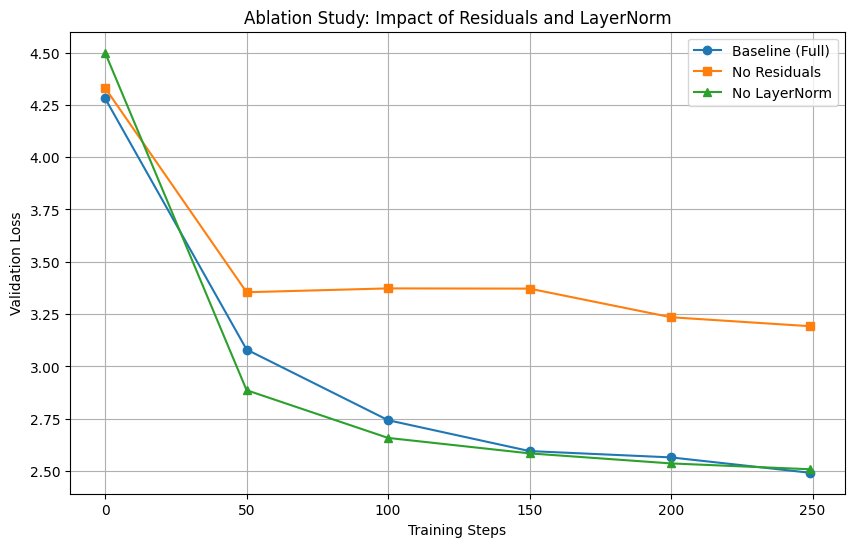

In [34]:
@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

def train_model(model_name, use_residual, use_ln):
    print(f"\n--- Training {model_name} ---")
    model = TransformerModel(use_residual=use_residual, use_ln=use_ln).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    
    loss_history = []
    
    for iter in range(max_iters):
        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss(model)
            loss_history.append((iter, losses['val'].item()))
            print(f"Step {iter:03d}: val loss {losses['val']:.4f}")

        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
    return model, loss_history

# 1. Train Baseline
baseline_model, baseline_losses = train_model("Variant 1 - Baseline", use_residual=True, use_ln=True)

# 2. Train Variant 2 (No Residuals)
_, no_res_losses = train_model("Variant 2 - No Residuals", use_residual=False, use_ln=True)

# 3. Train Variant 3 (No LayerNorm)
_, no_ln_losses = train_model("Variant 3 - No LayerNorm", use_residual=True, use_ln=False)

# --- Plotting ---
iters = [x[0] for x in baseline_losses]
plt.figure(figsize=(10, 6))
plt.plot(iters, [x[1] for x in baseline_losses], label='Baseline (Full)', marker='o')
plt.plot(iters, [x[1] for x in no_res_losses], label='No Residuals', marker='s')
plt.plot(iters, [x[1] for x in no_ln_losses], label='No LayerNorm', marker='^')

plt.xlabel('Training Steps')
plt.ylabel('Validation Loss')
plt.title('Ablation Study: Impact of Residuals and LayerNorm')
plt.legend()
plt.grid(True)
plt.savefig('ablation_plot.png')
print("\nSuccess: Saved 'ablation_plot.png'")

In [35]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_tokens = baseline_model.generate(context, max_new_tokens=300)[0].tolist()
generated_text = decode(generated_tokens)

print("Generated Text:\n")
print(generated_text)

with open('samples.txt', 'w', encoding='utf-8') as f:
    f.write(generated_text)
print("\nSuccess: Saved text to 'samples.txt'")

Generated Text:


Shofw Ithe waCan boudee o d tomelery sakin red d anou I, er!
Geed ming ofoLGSEEQoufome?
Wave d nonuned; fotlt ain Thid gaens corer ad fipfu laemper thandy Lvervam ware herd sfuror m:
Iss
Mondhavan t wtlescy thond d teer I wotanonloller d m uespif y thacertom icouchamo?
Hely me millen m tancoly&oilon

Success: Saved text to 'samples.txt'
